# 03 — Periodic Phase Encoding (Sub-contribution 1)

Vanilla DP에 phase 정보를 가장 단순하게 주입한 버전. PAPL과 거의 동일한 conditioning 방식 (chunk 첫 step의 phase 1개를 (cos φ, sin φ) 2차원으로 인코딩 후 global_cond에 concat).

**Vanilla DP (02) 대비 변경**:
| 항목 | Vanilla | Periodic Phase |
|---|---|---|
| `global_cond_dim` | OH × OD = 210 | OH × OD + 2 = 212 |
| `cond_fn` (train) | `vanilla_cond_fn` | `periodic_phase_cond_fn` |
| `cond_fn` (sample) | `vanilla_sample_cond_fn` | `periodic_phase_sample_cond_fn` |
| Rollout phase | 없음 | `phase_trajectory_fn` (시간 기반 외삽) |

**핵심 평가 — sampling-time controllability**: 학습은 freq ≈ 2.02 Hz 단일 mode로 하지만, rollout 시점에 phase trajectory의 freq를 바꿔서 모델 출력이 실제로 변하는지 확인. 이게 sub-contribution 1의 검증.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
PROJECT_DIR = '/content/drive/MyDrive/quadruped_diffusion_project'
SRC_DIR = f'{PROJECT_DIR}/src'
assert os.path.exists(SRC_DIR), f"src 폴더 없음: {SRC_DIR}"
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f"✓ Drive mounted")
print(f"  src 파일: {[f for f in os.listdir(SRC_DIR) if f.endswith('.py')]}")

Mounted at /content/drive
✓ Drive mounted
  src 파일: ['sampling.py', 'dataset.py', 'training.py', 'models.py']


In [2]:
!pip install -q "diffusers>=0.30,<0.32" "huggingface_hub>=0.23" "gymnasium[mujoco]"
print("✓ 의존성 준비 완료")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 21.0 MB/s eta 0:00:00
✓ 의존성 준비 완료


In [3]:
import time
import shutil
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
from diffusers.training_utils import EMAModel

from dataset  import load_project_data, build_loaders
from models   import build_periodic_phase_dp_model, count_params
from training import (
    train_diffusion_policy, periodic_phase_cond_fn,
    save_checkpoint, load_checkpoint,
)
from sampling import (
    sample_action_chunk, rollout, rollout_multi_seed,
    periodic_phase_sample_cond_fn, diagnose_obs_distribution,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch {torch.__version__}, device={device}")

PyTorch 2.10.0+cu128, device=cuda


## 2. 데이터 로드 + DataLoader

In [5]:
data = load_project_data(PROJECT_DIR)

print(f"OBS_DIM={data['OBS_DIM']}, ACT_DIM={data['ACT_DIM']}")
print(f"Freq window: {data['freq_window_mean']:.3f} ± {data['freq_window_std']:.3f} Hz "
      f"(range [{data['freq_window_min']:.3f}, {data['freq_window_max']:.3f}])")

SEED = data['seed']
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

BATCH_SIZE = 256
train_ds, val_ds, train_loader, val_loader = build_loaders(
    data, batch_size=BATCH_SIZE, num_workers=2,
)

OBS_DIM=105, ACT_DIM=8
Freq window: 2.023 ± 0.102 Hz (range [1.800, 2.300])
Train dataset:
  AntPhaseDataset: 102 episodes → 18768 chunks
Val dataset:
  AntPhaseDataset: 18 episodes → 3312 chunks
  Train batches/epoch: 73
  Val batches/epoch:   13


## 3. 모델 빌드 — Periodic Phase Encoding

`global_cond_dim = OH × OD + 2`. 추가 2차원에 `(cos φ_0, sin φ_0)`이 들어감.

In [6]:
model = build_periodic_phase_dp_model(
    obs_dim=data['OBS_DIM'],
    act_dim=data['ACT_DIM'],
    obs_horizon=data['OBS_HORIZON'],
    diffusion_step_embed_dim=256,
    down_dims=(256, 512, 1024),
    device=device,
)
n = count_params(model)
print(f"Total params:     {n['total']/1e6:.2f}M")
print(f"Trainable params: {n['trainable']/1e6:.2f}M")
print(f"global_cond_dim:  {data['OBS_HORIZON'] * data['OBS_DIM']} + 2 = "
      f"{data['OBS_HORIZON'] * data['OBS_DIM'] + 2}")

# Sanity forward
B = 4
fake_action = torch.randn(B, data['PRED_HORIZON'], data['ACT_DIM'], device=device)
fake_t = torch.randint(0, 100, (B,), device=device)
fake_cond = torch.randn(B, data['OBS_HORIZON'] * data['OBS_DIM'] + 2, device=device)
with torch.no_grad():
    out = model(fake_action, fake_t, fake_cond)
assert out.shape == fake_action.shape
print(f"✓ Forward pass: in {tuple(fake_action.shape)} → out {tuple(out.shape)}")

Total params:     68.26M
Trainable params: 68.26M
global_cond_dim:  210 + 2 = 212
✓ Forward pass: in (4, 16, 8) → out (4, 16, 8)


## 4. Conditioning 추출 sanity

`periodic_phase_cond_fn`이 batch에서 phase를 제대로 뽑아 (cos, sin)으로 변환하는지 확인.

In [7]:
sample_batch = next(iter(train_loader))
print("Batch keys + shapes:")
for k, v in sample_batch.items():
    print(f"  {k}: {tuple(v.shape)}")

global_cond, per_step_cond = periodic_phase_cond_fn(sample_batch, device)
print(f"\nglobal_cond shape: {tuple(global_cond.shape)}  (B, OH×OD + 2)")
print(f"per_step_cond:     {per_step_cond}  (Step 3에서는 None)")

# Phase 인코딩 검증: cos²+sin² = 1
phase_enc = global_cond[:, -2:]
norms = (phase_enc ** 2).sum(dim=1).sqrt()
print(f"\n(cos² + sin²) ^ 0.5: mean={norms.mean():.6f}, std={norms.std():.6f}")
assert torch.allclose(norms, torch.ones_like(norms), atol=1e-5), "Phase 인코딩 이상"
print("✓ Phase encoding 정합")

Batch keys + shapes:
  obs: (256, 2, 105)
  action: (256, 16, 8)
  phase: (256, 16)

global_cond shape: (256, 212)  (B, OH×OD + 2)
per_step_cond:     None  (Step 3에서는 None)

(cos² + sin²) ^ 0.5: mean=1.000000, std=0.000000
✓ Phase encoding 정합


## 5. Noise scheduler (Vanilla DP와 동일)

In [8]:
NUM_TRAIN_TIMESTEPS = 100
NUM_INFERENCE_STEPS  = 16

noise_scheduler = DDPMScheduler(
    num_train_timesteps=NUM_TRAIN_TIMESTEPS,
    beta_schedule='squaredcos_cap_v2',
    prediction_type='epsilon',
    clip_sample=True,
)
ns_config = {
    'num_train_timesteps': noise_scheduler.config.num_train_timesteps,
    'beta_schedule':       noise_scheduler.config.beta_schedule,
    'prediction_type':     noise_scheduler.config.prediction_type,
    'clip_sample':         noise_scheduler.config.clip_sample,
}
print(f"DDPM: {NUM_TRAIN_TIMESTEPS} train steps, "
      f"DDIM inference: {NUM_INFERENCE_STEPS} steps")

DDPM: 100 train steps, DDIM inference: 16 steps


## 6. 학습 또는 ckpt 로드

**중요한 hyperparam 변경**: `NUM_EPOCHS=60` (Vanilla DP는 100이었지만 epoch 50에서 best였음. 60으로 줄이면 학습 시간 절약 + cosine schedule이 best 근처에서 끝남).

In [9]:
TRAIN = True   # 첫 실행시 True. 재실행시 False로 바꿔서 ckpt 로드.
NUM_EPOCHS = 60
CKPT_PATH = f'{PROJECT_DIR}/phase_periodic_ckpt.pt'

ema = EMAModel(parameters=model.parameters(), power=0.75)

if TRAIN:
    train_losses, val_log, best_ema_state = train_diffusion_policy(
        model, ema, noise_scheduler,
        train_loader, val_loader,
        cond_fn=periodic_phase_cond_fn,
        num_epochs=NUM_EPOCHS,
        lr=1e-4,
        weight_decay=1e-6,
        warmup_steps=500,
        val_every=5,
        log_every_step=100,
        device=device,
    )
    save_checkpoint(
        CKPT_PATH, model, ema, train_losses, val_log, best_ema_state,
        config={
            'OBS_DIM': data['OBS_DIM'], 'ACT_DIM': data['ACT_DIM'],
            'OBS_HORIZON':  data['OBS_HORIZON'],
            'PRED_HORIZON': data['PRED_HORIZON'],
            'NUM_TRAIN_TIMESTEPS': NUM_TRAIN_TIMESTEPS,
            'NUM_INFERENCE_STEPS': NUM_INFERENCE_STEPS,
            'phase_encoding': 'periodic_first_step',
        },
    )
else:
    meta = load_checkpoint(CKPT_PATH, model, ema, device=device, use_best_ema=True)
    train_losses   = meta['train_losses']
    val_log        = meta['val_log']
    best_ema_state = meta['best_ema_state']

  step 100/4380 | epoch 2/60 | loss 0.96454 | lr 2.00e-05 | elapsed 28s
  step 200/4380 | epoch 3/60 | loss 0.32719 | lr 4.00e-05 | elapsed 56s
  step 300/4380 | epoch 5/60 | loss 0.21904 | lr 6.00e-05 | elapsed 85s
  >> epoch 5: train 0.20671 | val 0.19311
     ★ new best val
  step 400/4380 | epoch 6/60 | loss 0.19583 | lr 8.00e-05 | elapsed 116s
  step 500/4380 | epoch 7/60 | loss 0.18149 | lr 1.00e-04 | elapsed 148s
  step 600/4380 | epoch 9/60 | loss 0.16449 | lr 9.98e-05 | elapsed 178s
  step 700/4380 | epoch 10/60 | loss 0.16560 | lr 9.93e-05 | elapsed 209s
  >> epoch 10: train 0.16372 | val 0.16210
     ★ new best val
  step 800/4380 | epoch 11/60 | loss 0.16109 | lr 9.85e-05 | elapsed 241s
  step 900/4380 | epoch 13/60 | loss 0.15633 | lr 9.74e-05 | elapsed 271s
  step 1000/4380 | epoch 14/60 | loss 0.14819 | lr 9.60e-05 | elapsed 302s
  >> epoch 15: train 0.14904 | val 0.14190
     ★ new best val
  step 1100/4380 | epoch 16/60 | loss 0.14150 | lr 9.42e-05 | elapsed 334s
  ste

## 7. Loss curve

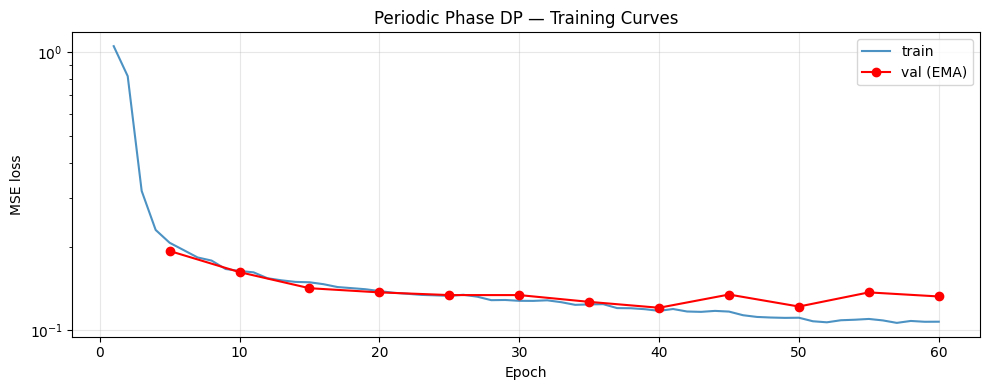

✓ /content/drive/MyDrive/quadruped_diffusion_project/phase_periodic_loss.png

=== Loss 비교 ===
Vanilla DP   final train=0.0832, best val=0.1192
Periodic DP  final train=0.1075, best val=0.1207


In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(np.arange(1, len(train_losses) + 1), train_losses, label='train', alpha=0.8)
if val_log:
    ax.plot([v[0] for v in val_log], [v[1] for v in val_log],
            'o-', label='val (EMA)', color='red')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss')
ax.set_title('Periodic Phase DP — Training Curves')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale('log')
plt.tight_layout()
out_png = f'{PROJECT_DIR}/phase_periodic_loss.png'
plt.savefig(out_png, dpi=80, bbox_inches='tight')
plt.show()
print(f"✓ {out_png}")

# Vanilla DP와 비교 (있으면)
vanilla_ckpt = f'{PROJECT_DIR}/vanilla_dp_ckpt.pt'
if os.path.exists(vanilla_ckpt):
    v_ckpt = torch.load(vanilla_ckpt, map_location='cpu')
    v_train = v_ckpt['train_losses']
    v_val = v_ckpt['val_log']
    print(f"\n=== Loss 비교 ===")
    print(f"Vanilla DP   final train={v_train[-1]:.4f}, best val={min(v[1] for v in v_val):.4f}")
    print(f"Periodic DP  final train={train_losses[-1]:.4f}, best val={min(v[1] for v in val_log):.4f}")

## 8. Best EMA 적용 컨펌

`load_checkpoint(use_best_ema=True)`가 이미 적용해줬지만, `TRAIN=True`로 학습 직후엔 `ema` 객체가 final epoch 상태야. 학습 후 best EMA로 sampling하려면 명시적으로 적용 필요.

In [11]:
# 학습 직후 (TRAIN=True 경로)에서만 의미 있음
if TRAIN and best_ema_state is not None:
    cur = ema.state_dict()
    cur.update(best_ema_state)
    ema.load_state_dict(cur)
    best_idx = min(range(len(val_log)), key=lambda i: val_log[i][1])
    print(f"✓ Best EMA 적용 (epoch {val_log[best_idx][0]}, val={val_log[best_idx][1]:.5f})")
elif not TRAIN:
    print("Load 경로 — 이미 best EMA 적용됨")
else:
    print("⚠ best_ema_state 없음")

✓ Best EMA 적용 (epoch 40, val=0.12069)


## 9. Phase trajectory function — 시간 기반 외삽 (옵션 A)

Rollout 중 phase를 환경에서 직접 측정하지 않고, 시간(step)을 기반으로 외삽:

$$\varphi(t) = (2\pi \cdot f \cdot t \cdot dt) \bmod 2\pi$$

- `f`: 원하는 보행 frequency (Hz)
- `dt`: simulation timestep (Ant-v5 default 0.05s)

**핵심 — controllability test**: 학습 freq window는 [1.82, 2.23] Hz. Sampling 시 `f`를 바꿔가며:
- `f = freq_window_mean`: in-distribution baseline
- `f` slow: in-distribution lower edge
- `f` fast: in-distribution upper edge
- `f` mild OOD: 학습 영역 밖 (controllability 한계 측정)

In [12]:
DT = 0.05  # Ant-v5 default

def make_phase_traj_fn(freq_hz: float, dt: float = DT):
    """Return phase_trajectory_fn closure for given freq."""
    def phase_traj(current_step: int, pred_horizon: int):
        t_steps = np.arange(current_step, current_step + pred_horizon)
        phi = (2.0 * np.pi * freq_hz * t_steps * dt) % (2.0 * np.pi)
        return phi.astype(np.float32)
    return phase_traj

# 테스트
f_mean = data['freq_window_mean']
test_fn = make_phase_traj_fn(f_mean)
phi = test_fn(0, data['PRED_HORIZON'])
expected_per_step = 2 * np.pi * f_mean * DT
print(f"Test (freq={f_mean:.3f} Hz):")
print(f"  φ(0..{data['PRED_HORIZON']-1}): {phi[:4].round(3)}, ..., {phi[-2:].round(3)}")
print(f"  Per-step Δφ (unwrap): {np.diff(np.unwrap(phi)).mean():.4f} rad/step")
print(f"  Expected:             {expected_per_step:.4f} rad/step")

Test (freq=2.023 Hz):
  φ(0..15): [0.    0.636 1.271 1.907], ..., [2.616 3.252]
  Per-step Δφ (unwrap): 0.6356 rad/step
  Expected:             0.6356 rad/step


## 10. Offline sampling sanity — phase 영향 검증

같은 obs window에 대해 (1) phase 없는 vanilla 호출 vs (2) 다른 freq의 phase trajectory를 줬을 때 sampled action이 실제로 다르게 나오는지 확인. 만약 출력이 거의 같으면 모델이 phase를 무시하고 학습한 거.

In [13]:
# Val set의 obs window 1개로 다양한 freq trajectory 샘플링
ep_obs = torch.stack([val_ds[0]['obs']]).to(device)  # (1, OH, OD)

# Phase trajectories: in-dist + edges + mild OOD
freqs_to_test = [
    f_mean,                                          # 학습 mean
    data['freq_window_min'],                         # 학습 min
    data['freq_window_max'],                         # 학습 max
    f_mean - 3 * data['freq_window_std'],            # mild OOD low
    f_mean + 3 * data['freq_window_std'],            # mild OOD high
]
labels = ['mean', 'min', 'max', 'OOD-low', 'OOD-high']

samples_by_freq = {}
for f, lbl in zip(freqs_to_test, labels):
    phi = make_phase_traj_fn(f)(0, data['PRED_HORIZON'])
    phi_t = torch.from_numpy(phi).unsqueeze(0)  # (1, PH)
    s = sample_action_chunk(
        model, ema, ns_config,
        obs_window=ep_obs, phase_chunk=phi_t,
        cond_fn=periodic_phase_sample_cond_fn,
        pred_horizon=data['PRED_HORIZON'],
        act_dim=data['ACT_DIM'],
        num_inference_steps=NUM_INFERENCE_STEPS,
        device=device, use_ema=True,
    ).numpy()[0]
    samples_by_freq[lbl] = (f, s)
    print(f"  {lbl:>9s} freq={f:.3f} Hz: action chunk mean={s.mean():.3f}, std={s.std():.3f}")

       mean freq=2.023 Hz: action chunk mean=-0.087, std=0.348
        min freq=1.800 Hz: action chunk mean=-0.085, std=0.340
        max freq=2.300 Hz: action chunk mean=-0.094, std=0.364
    OOD-low freq=1.717 Hz: action chunk mean=-0.063, std=0.384
   OOD-high freq=2.330 Hz: action chunk mean=-0.072, std=0.360


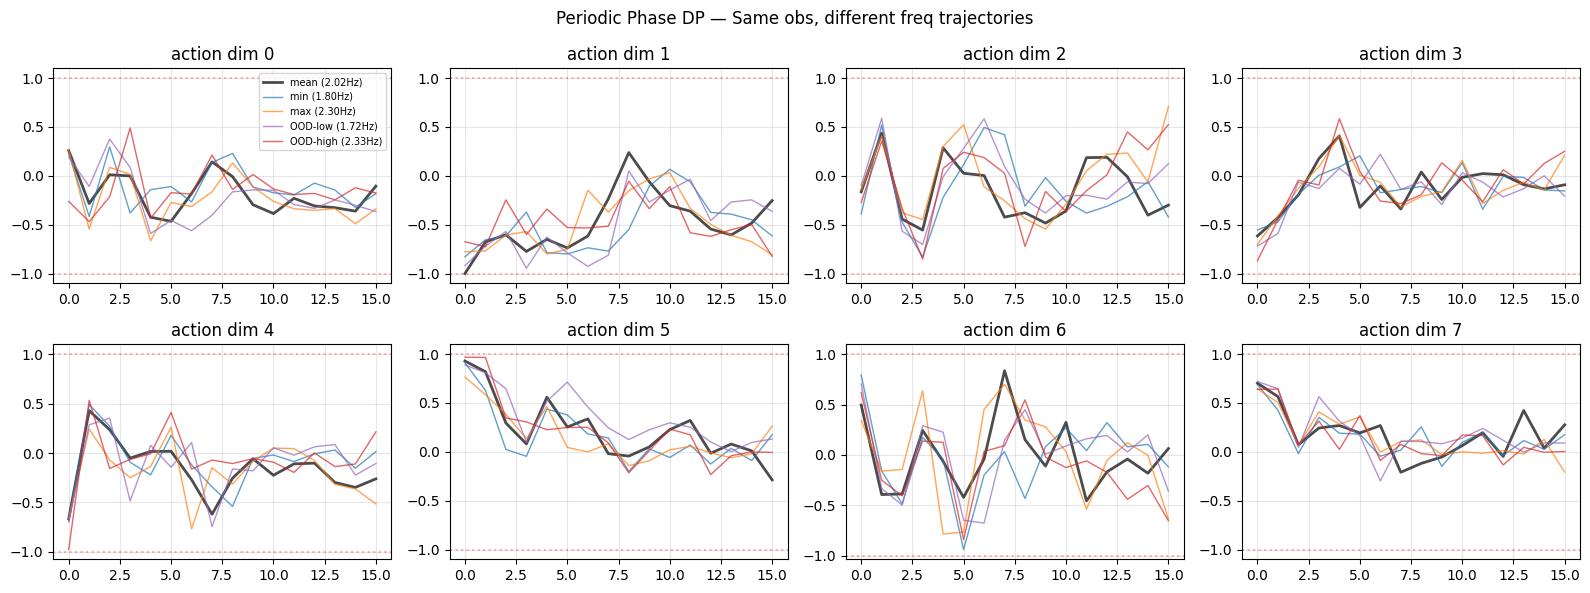

✓ /content/drive/MyDrive/quadruped_diffusion_project/phase_periodic_freq_sweep.png

=== Output 차이 (L2 distance from 'mean' baseline) ===
       mean (Δf=+0.000 Hz): RMSE = 0.0000
        min (Δf=-0.223 Hz): RMSE = 0.2642
        max (Δf=+0.277 Hz): RMSE = 0.2472
    OOD-low (Δf=-0.307 Hz): RMSE = 0.2518
   OOD-high (Δf=+0.307 Hz): RMSE = 0.2663

→ Δf↑ 일수록 RMSE↑ 면 phase가 실제로 영향. 모두 비슷하면 모델이 phase 무시.


In [14]:
# 시각화: action dim 0~3을 freq별로 비교
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
colors = {'mean': 'k', 'min': 'tab:blue', 'max': 'tab:orange',
          'OOD-low': 'tab:purple', 'OOD-high': 'tab:red'}
for d in range(data['ACT_DIM']):
    ax = axes.flat[d]
    for lbl, (f, s) in samples_by_freq.items():
        lw = 2 if lbl == 'mean' else 1
        ax.plot(s[:, d], '-', alpha=0.7, linewidth=lw,
                label=f'{lbl} ({f:.2f}Hz)' if d == 0 else None,
                color=colors[lbl])
    ax.axhline( 1, color='r', ls=':', alpha=0.3)
    ax.axhline(-1, color='r', ls=':', alpha=0.3)
    ax.set_title(f'action dim {d}')
    ax.grid(True, alpha=0.3)
    if d == 0:
        ax.legend(fontsize=7)
plt.suptitle('Periodic Phase DP — Same obs, different freq trajectories')
plt.tight_layout()
out_png = f'{PROJECT_DIR}/phase_periodic_freq_sweep.png'
plt.savefig(out_png, dpi=80, bbox_inches='tight')
plt.show()
print(f"✓ {out_png}")

# 정량: 각 freq trajectory output 사이의 평균 거리
print(f"\n=== Output 차이 (L2 distance from 'mean' baseline) ===")
ref = samples_by_freq['mean'][1]
for lbl, (f, s) in samples_by_freq.items():
    d = np.linalg.norm(s - ref) / np.sqrt(s.size)
    print(f"  {lbl:>9s} (Δf={f - f_mean:+.3f} Hz): RMSE = {d:.4f}")
print(f"\n→ Δf↑ 일수록 RMSE↑ 면 phase가 실제로 영향. 모두 비슷하면 모델이 phase 무시.")

## 11. Ant rollout — In-distribution

학습 mean freq로 rollout. Vanilla DP와 비교.

In [15]:
import gymnasium as gym
env = gym.make('Ant-v5')
test_obs, _ = env.reset(seed=SEED)
print(f"Ant-v5 obs dim: {test_obs.shape[0]} (학습: {data['OBS_DIM']})")

Ant-v5 obs dim: 105 (학습: 105)


In [16]:
print(f"=== Periodic Phase DP — Rollout @ f={f_mean:.3f} Hz (in-dist mean) ===\n")

phase_fn_mean = make_phase_traj_fn(f_mean)

results_in = rollout_multi_seed(
    model, ema, env, n_seeds=5,
    noise_scheduler_config=ns_config,
    obs_mean=data['obs_mean'], obs_std=data['obs_std'],
    act_min=data['act_min'], act_range=data['act_range'],
    cond_fn=periodic_phase_sample_cond_fn,
    obs_horizon=data['OBS_HORIZON'],
    pred_horizon=data['PRED_HORIZON'],
    action_horizon=data['ACTION_HORIZON'],
    obs_dim=data['OBS_DIM'],
    act_dim=data['ACT_DIM'],
    num_inference_steps=NUM_INFERENCE_STEPS,
    max_steps=300,
    phase_trajectory_fn=phase_fn_mean,
    device=device,
)

=== Periodic Phase DP — Rollout @ f=2.023 Hz (in-dist mean) ===

  seed 0: survival=300 steps, total_reward=   313.7
  seed 1: survival=300 steps, total_reward=   296.7
  seed 2: survival=300 steps, total_reward=   422.5
  seed 3: survival=300 steps, total_reward=   232.9
  seed 4: survival=300 steps, total_reward=   197.8

Survival:  mean=300 ± 0 steps
Reward:    mean=292.7 ± 77.3


## 12. Controllability sweep — 핵심 평가

학습 영역 안에서 freq를 바꾸며 rollout. 모델이 phase를 진짜로 활용한다면 freq별로 보행 패턴(reward 구성)이 달라져야 함. 모두 동일하면 phase가 "장식"이라는 뜻.

In [20]:
# Sweep 범위: in-dist edges + mild OOD
sweep_freqs = np.array([
    f_mean - 3 * data['freq_window_std'],   # mild OOD
    data['freq_window_min'],                 # in-dist min
    f_mean - data['freq_window_std'],        # in-dist
    f_mean,                                  # in-dist mean
    f_mean + data['freq_window_std'],        # in-dist
    data['freq_window_max'],                 # in-dist max
    f_mean + 3 * data['freq_window_std'],    # mild OOD
])

sweep_results = {}
for f in sweep_freqs:
    phase_fn = make_phase_traj_fn(f)
    label = 'OOD' if f < data['freq_window_min'] - 0.01 or f > data['freq_window_max'] + 0.01 else 'in-dist'
    print(f"\n--- freq={f:.3f} Hz ({label}) ---")
    res = rollout_multi_seed(
        model, ema, env, n_seeds=3,    # 시간 절약 위해 3 seed
        noise_scheduler_config=ns_config,
        obs_mean=data['obs_mean'], obs_std=data['obs_std'],
        act_min=data['act_min'], act_range=data['act_range'],
        cond_fn=periodic_phase_sample_cond_fn,
        obs_horizon=data['OBS_HORIZON'],
        pred_horizon=data['PRED_HORIZON'],
        action_horizon=data['ACTION_HORIZON'],
        obs_dim=data['OBS_DIM'],
        act_dim=data['ACT_DIM'],
        num_inference_steps=NUM_INFERENCE_STEPS,
        max_steps=1000,
        phase_trajectory_fn=phase_fn,
        device=device,
    )
    sweep_results[float(f)] = res


--- freq=1.717 Hz (OOD) ---
  seed 0: survival=1000 steps, total_reward=   658.9
  seed 1: survival=1000 steps, total_reward=  1087.2
  seed 2: survival=1000 steps, total_reward=   746.9

Survival:  mean=1000 ± 0 steps
Reward:    mean=831.0 ± 184.7

--- freq=1.800 Hz (in-dist) ---
  seed 0: survival=1000 steps, total_reward=   695.5
  seed 1: survival=1000 steps, total_reward=   794.5
  seed 2: survival=1000 steps, total_reward=   939.6

Survival:  mean=1000 ± 0 steps
Reward:    mean=809.8 ± 100.3

--- freq=1.921 Hz (in-dist) ---
  seed 0: survival=140 steps, total_reward=   211.0
  seed 1: survival=1000 steps, total_reward=   669.6
  seed 2: survival=1000 steps, total_reward=   731.6

Survival:  mean=713 ± 405 steps
Reward:    mean=537.4 ± 232.2

--- freq=2.023 Hz (in-dist) ---
  seed 0: survival=1000 steps, total_reward=   808.1
  seed 1: survival=1000 steps, total_reward=  1019.8
  seed 2: survival=1000 steps, total_reward=   183.6

Survival:  mean=1000 ± 0 steps
Reward:    mean=67

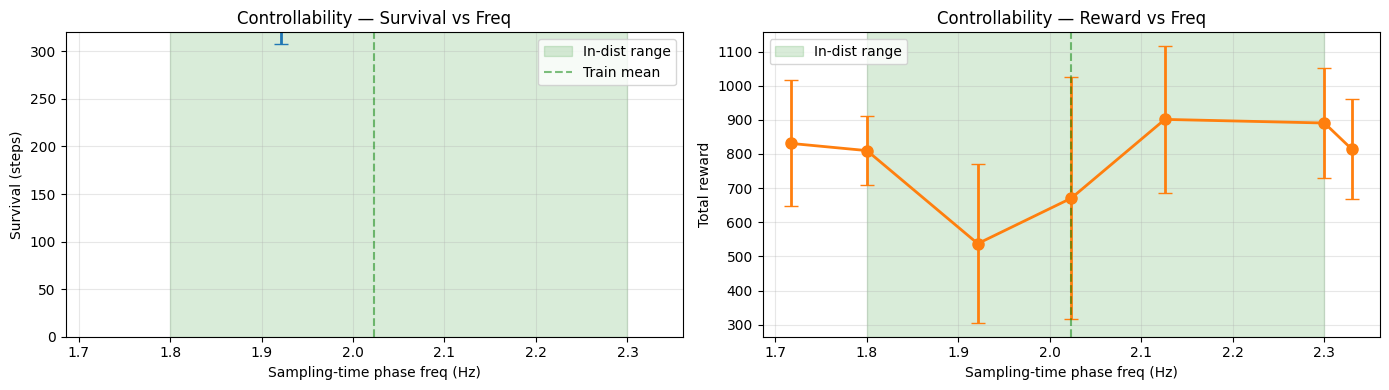

✓ /content/drive/MyDrive/quadruped_diffusion_project/phase_periodic_controllability.png

   freq |      survival |          reward | zone
  1.717 |  1000 ±    0 |   831.0 ± 184.7 | OOD
  1.800 |  1000 ±    0 |   809.8 ± 100.3 | in-dist
  1.921 |   713 ±  405 |   537.4 ± 232.2 | in-dist
  2.023 |  1000 ±    0 |   670.5 ± 355.0 | in-dist
  2.126 |  1000 ±    0 |   901.3 ± 214.5 | in-dist
  2.300 |  1000 ±    0 |   890.7 ± 162.1 | in-dist
  2.330 |  1000 ±    0 |   813.7 ± 146.8 | OOD


In [21]:
# Sweep 결과 시각화
sweep_freqs_sorted = sorted(sweep_results.keys())
surv_means = [np.mean([r['survival'] for r in sweep_results[f]]) for f in sweep_freqs_sorted]
surv_stds  = [np.std([r['survival']  for r in sweep_results[f]]) for f in sweep_freqs_sorted]
rew_means  = [np.mean([r['total_reward'] for r in sweep_results[f]]) for f in sweep_freqs_sorted]
rew_stds   = [np.std([r['total_reward']  for r in sweep_results[f]]) for f in sweep_freqs_sorted]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].errorbar(sweep_freqs_sorted, surv_means, yerr=surv_stds,
                 fmt='o-', capsize=5, linewidth=2, markersize=8)
axes[0].axvspan(data['freq_window_min'], data['freq_window_max'],
                alpha=0.15, color='green', label='In-dist range')
axes[0].axvline(f_mean, color='green', ls='--', alpha=0.5, label=f'Train mean')
axes[0].set_xlabel('Sampling-time phase freq (Hz)')
axes[0].set_ylabel('Survival (steps)')
axes[0].set_title('Controllability — Survival vs Freq')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 320)

axes[1].errorbar(sweep_freqs_sorted, rew_means, yerr=rew_stds,
                 fmt='o-', capsize=5, linewidth=2, markersize=8, color='tab:orange')
axes[1].axvspan(data['freq_window_min'], data['freq_window_max'],
                alpha=0.15, color='green', label='In-dist range')
axes[1].axvline(f_mean, color='green', ls='--', alpha=0.5)
axes[1].set_xlabel('Sampling-time phase freq (Hz)')
axes[1].set_ylabel('Total reward')
axes[1].set_title('Controllability — Reward vs Freq')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
out_png = f'{PROJECT_DIR}/phase_periodic_controllability.png'
plt.savefig(out_png, dpi=80, bbox_inches='tight')
plt.show()
print(f"✓ {out_png}")

# 표
print(f"\n{'freq':>7s} | {'survival':>13s} | {'reward':>15s} | zone")
for f in sweep_freqs_sorted:
    surv = np.array([r['survival'] for r in sweep_results[f]])
    rew  = np.array([r['total_reward'] for r in sweep_results[f]])
    zone = 'OOD' if (f < data['freq_window_min'] - 0.01
                     or f > data['freq_window_max'] + 0.01) else 'in-dist'
    print(f"{f:>7.3f} | {surv.mean():>5.0f} ± {surv.std():>4.0f} | "
          f"{rew.mean():>7.1f} ± {rew.std():>5.1f} | {zone}")

## 13. Vanilla vs Periodic 비교 (best EMA 기준)

Sub-contribution 1의 ablation 한 행. In-distribution mean freq에서 둘이 비슷하면 phase가 "useful" but not "necessary"라는 결과 (이게 정직한 결과). Periodic이 명확하게 좋으면 phase encoding 효과 입증. 만약 Vanilla가 더 좋다면 over-conditioning 가능성 있음 — 그땐 분석 필요.

In [19]:
print(f"=== In-distribution mean freq @ f={f_mean:.3f} Hz, 5 seeds ===\n")

# Periodic은 §11에서 이미 측정
periodic_surv = np.array([r['survival']     for r in results_in])
periodic_rew  = np.array([r['total_reward'] for r in results_in])

print(f"Periodic Phase DP:")
print(f"  Survival: {periodic_surv.mean():.0f} ± {periodic_surv.std():.0f}")
print(f"  Reward:   {periodic_rew.mean():.1f} ± {periodic_rew.std():.1f}")

# Vanilla DP 결과 (이미 보고됨)
print(f"\nVanilla DP (prev notebook):")
print(f"  Survival: 300 ± 0")
print(f"  Reward:   330.5 ± 96.0")

print(f"\n→ 동일 환경/seed에서 차이가 본 모델의 phase encoding 효과.")

=== In-distribution mean freq @ f=2.023 Hz, 5 seeds ===

Periodic Phase DP:
  Survival: 300 ± 0
  Reward:   292.7 ± 77.3

Vanilla DP (prev notebook):
  Survival: 300 ± 0
  Reward:   330.5 ± 96.0

→ 동일 환경/seed에서 차이가 본 모델의 phase encoding 효과.


## 14. 요약 + 다음 단계

**완료**:
- Periodic Phase Encoding (Sub-contribution 1) 학습 + 평가
- 시간 기반 phase trajectory로 controllability sweep
- Vanilla DP 대비 baseline 비교

**해석 가이드**:

§10 freq sweep RMSE 결과:
- `Δf` 클수록 RMSE 큼 → phase가 실제로 영향. 진행.
- 모두 비슷 → 모델이 phase를 무시. Phase encoding을 더 강하게 해야 (per-step FiLM = Step 4).

§12 controllability sweep:
- In-dist에서 reward/survival 변화 → phase로 보행 속도 조절 가능. 좋은 결과.
- OOD에서 reward 급락 → 학습 영역 한계. 정직한 결과.
- In-dist에서도 평탄 → phase가 chunk 첫 step에만 반영되는 한계 (Sub-contribution 2의 동기).

§13 Vanilla 비교:
- Periodic ≈ Vanilla → 첫 step phase는 충분한 정보 못 줌. Step 4 (per-step trajectory)에서 진짜 차이 기대.
- Periodic > Vanilla → phase encoding 자체가 도움.

**다음 단계 (`04_phase_trajectory.ipynb`) — Sub-contribution 2 (메인 novelty)**:

Per-step FiLM으로 phase trajectory 전체를 conditioning. 새 클래스 `PhaseConditionedUnet1D` 필요 — global_cond + per_step_cond 두 stream을 ResBlock 안에서 합침. 이게 진짜 차별 기여.